In [44]:
#Importing libraries and storing API key

import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image #imports the image module from the pillow libarary
from io import BytesIO #creates an in binary stream which temporarily stores the downloaded image data  in RAM so pillow can read it like a file

API_KEY = 'pDuztB79vX6hvBm7heeAKcCUZyX89TbcpJxlYtDY'




In [45]:
# APOD endpoint
url = f"https://api.nasa.gov/planetary/apod?api_key={API_KEY}"

# send request
response = requests.get(url)

# convert response to JSON
data = response.json()

# view returned data
print(data)

{'copyright': 'John Hayes', 'date': '2026-05-25', 'explanation': "What are these strange space globs?  Situated in rich star fields and glowing hydrogen gas, these opaque clouds of interstellar dust and gas are so large they might be able to form stars. Their home is known as IC 2944, a bright stellar nursery located about 7,600 light years away toward the constellation of the Centaur (Centaurus). The largest of these  dark globules, first spotted by A. D. Thackeray in 1950 using a telescope in South Africa, is likely two separate but overlapping clouds, each more than one light-year wide. Along with other data, the featured Hubble palette image from the El Sauce Observatory in Chile, indicates that Thackeray's globules are fractured and churning as a result of intense ultraviolet radiation from young, hot stars already energizing and heating the bright emission nebula. These and similar dark globules known to be associated with other star forming regions may ultimately be dissipated b

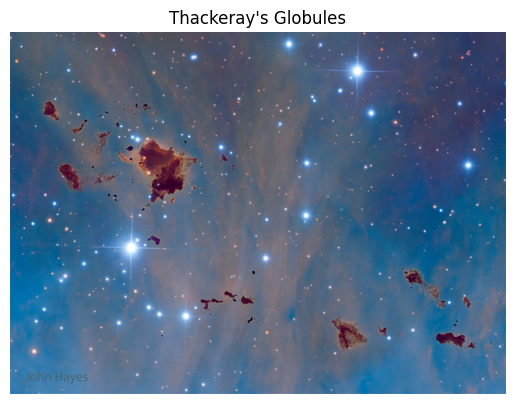

In [46]:
#displaying the picture

#get the image URL
image_url = data['url']

#request image
image_response = requests.get(image_url)

#opening the image
img = Image.open(BytesIO(image_response.content))


# display image
plt.imshow(img)
plt.axis('off')

# show title
plt.title(data['title'])

plt.show()




In [47]:
#ACCESS the API NeoWS API
neo_url = f'https://api.nasa.gov/neo/rest/v1/neo/browse?api_key={API_KEY}'

neo_response = requests.get(neo_url)

neo_data = neo_response.json()

print(neo_data.keys())

dict_keys(['links', 'page', 'near_earth_objects'])


In [48]:
#cleaning and processing the data 
asteroids = neo_data['near_earth_objects']

clean_data= []

for asteroid in asteroids:
    asteroid_id = asteroid['id']
    asteroid_name = asteroid['name']
    min_diameter = asteroid['estimated_diameter']['kilometers']['estimated_diameter_min']
    absolute_magnitude = asteroid['absolute_magnitude_h']

      # some asteroids may not have close approach data
    if asteroid['close_approach_data']:

        relative_velocity = asteroid['close_approach_data'][0]['relative_velocity']['kilometers_per_hour']

    else:
        relative_velocity = None

    clean_data.append({
        'Asteroid ID': asteroid_id,
        'Asteroid Name': asteroid_name,
        'Minimal Estimated Diameter (km)': min_diameter,
        'Absolute Magnitude': absolute_magnitude,
        'Relative Velocity (km/h)': relative_velocity
    })

In [59]:
#Convert the cleaned data into a dataframe
df = pd.DataFrame(clean_data)
print(df.head())

  Asteroid ID                Asteroid Name  Minimal Estimated Diameter (km)  \
0     2001620    1620 Geographos (1951 RA)                         2.358061   
1     2001863      1863 Antinous (1948 EA)                         2.262325   
2     2001915  1915 Quetzalcoatl (1953 EA)                         0.560473   
3     2001917          1917 Cuyo (1968 AA)                         3.536348   
4     2002063       2063 Bacchus (1977 HB)                         0.960627   

   Absolute Magnitude Relative Velocity (km/h)  
0               15.26         42346.1219923274  
1               15.35         65086.2508940392  
2               18.38         54435.5501077667  
3               14.38         54844.1633277299  
4               17.21         37400.8037755259  


In [ ]:
#checking for missing values
print(df.isnull().sum())




Asteroid ID                        0
Asteroid Name                      0
Minimal Estimated Diameter (km)    0
Absolute Magnitude                 0
Relative Velocity (km/h)           2
dtype: int64


In [62]:
#removing rows with missing values
df.dropna(inplace=True)

In [ ]:
#checking the data type of relative velocity column
print(df['Relative Velocity (km/h)'].dtype)

float64


In [ ]:
#changing the data type of relative velocity to numeric
df['Relative Velocity (km/h)'] = pd.to_numeric(
    df['Relative Velocity (km/h)']
)

In [67]:
#exporting the cleaned data to a CSV file
df.to_csv('asteroids.csv', index=False)

print("CSV file saved successfully!")


CSV file saved successfully!
